# Nome: Erison de Almeida Gueds
# Matrícula: (2250817)

## Import all packages need in the cell below

In [12]:
#Pkg.add("Optim")
#Pkg.add("NLsolve")
#Pkg.add("ForwardDiff")

using Plots           # para gerar os gráficos
using JuMP            # modelar
using Ipopt           # Variaveis não lineares
using GLPK            # lineares e inteiros
using LinearAlgebra   # operações matriciais
using Statistics      # regressão
using Pkg
using Optim
using NLsolve
using ForwardDiff


## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

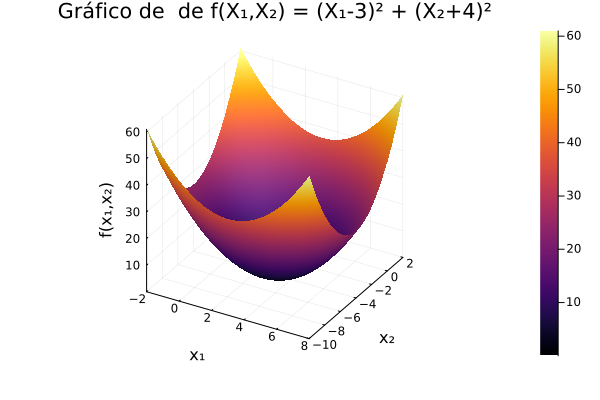

In [11]:
# Definindo a função
f(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

# Intervalos
x1 = range(-2, 8, length=200)
x2 = range(-10, 2, length=200)

# Superfície 3D
surface(x1, x2, f,
    xlabel="x₁",
    ylabel="x₂",
    zlabel="f(x₁,x₂)",
    title="Gráfico de  de f(X₁,X₂) = (X₁-3)² + (X₂+4)²"
)

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [ ]:
println(" Optim + NLsolve usando o próprio código")

# Função objetivo
f(x) = (x[1] - 1)^4 + (x[2] - 2)^4

# Chute inicial
x0 = [0.0, 0.0]

# 1) Minimização com Optim
res = optimize(f, x0)

x_otimo = Optim.minimizer(res)
z_min = Optim.minimum(res)

println("\nResultado do Optim:")
println("x_otimo = ", x_otimo)
println("z_min   = ", z_min)

# 2) FONC
function F!(Fvec, x)
    Fvec .= ForwardDiff.gradient(f, x)
end

# 3) Resolver FONC usando o resultado do Optim como chute inicial
sol = nlsolve(F!, x_otimo)

println("\nResultado do NLsolve:")
println("solução = ", sol.zero)

# 4) Verificação do gradiente
println("\nGradiente no ponto encontrado:")
println(ForwardDiff.gradient(f, sol.zero))

 Optim + NLsolve usando o próprio código

Resultado do Optim:
x_otimo = [0.9981447581936664, 1.9992588410321355]
z_min   = 1.2148576899502346e-11

Resultado do NLsolve:
solução = [0.9987631699330239, 1.9995058720509682]

Gradiente no ponto encontrado:
[-7.568156325690263e-9, -4.825899230945153e-10]


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

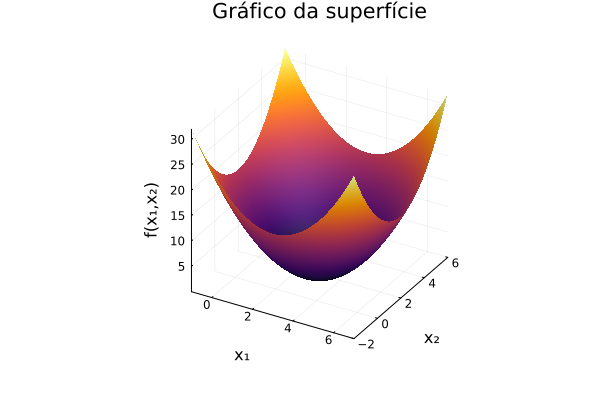

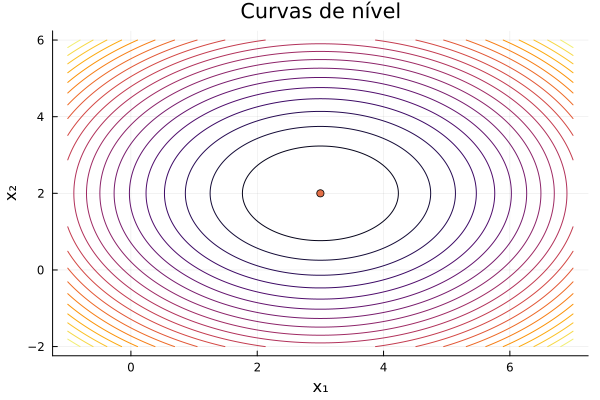

In [17]:
using Plots

gr()

# Função
f(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

# Intervalos
x1 = range(-1, 7, length=200)
x2 = range(-2, 6, length=200)

# -----------------------------
# 1) Gráfico da superfície
# -----------------------------
p1 = surface(
    x1, x2, f,
    xlabel = "x₁",
    ylabel = "x₂",
    zlabel = "f(x₁,x₂)",
    title = "Gráfico da superfície",
    legend = false
)

display(p1)

# -----------------------------
# 2) Curvas de nível
# -----------------------------
p2 = contour(
    x1, x2, f,
    xlabel = "x₁",
    ylabel = "x₂",
    title = "Curvas de nível",
    levels = 20,
    legend = false
)

scatter!(p2, [3], [2], markersize = 4)

display(p2)

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [26]:
# Função
f(x) = (x[1] - 3)^2 + (x[2] - 2)^2

# Gradiente
grad_f(x) = ForwardDiff.gradient(f, x)

# Hessiana
hess_f(x) = ForwardDiff.hessian(f, x)

# =========================
# Gradiente Descendente
# =========================
function gradient_descent(x0; α=0.1, maxiter=10)
    x = copy(x0)

    println("=== Gradiente Descendente ===")

    for k in 0:maxiter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        x = x - α * g
    end
end

# =========================
# Método de Newton
# =========================
function newton_method(x0; maxiter=2)
    x = copy(x0)

    println("\n=== Método de Newton ===")

    for k in 0:maxiter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        x = x - H \ g
    end
end

# Ponto inicial
x0 = [1.0, 1.0]

gradient_descent(x0)
newton_method(x0)

=== Gradiente Descendente ===

Iteração 0
x = [1.0, 1.0]
f(x) = 5.0
gradiente = [-4.0, -2.0]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 1
x = [1.4, 1.2]
f(x) = 3.2000000000000006
gradiente = [-3.2, -1.6]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 2
x = [1.72, 1.3599999999999999]
f(x) = 2.048
gradiente = [-2.56, -1.2800000000000002]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 3
x = [1.976, 1.488]
f(x) = 1.3107199999999999
gradiente = [-2.048, -1.024]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 4
x = [2.1808, 1.5904]
f(x) = 0.8388607999999999
gradiente = [-1.6383999999999999, -0.8191999999999999]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 5
x = [2.34464, 1.67232]
f(x) = 0.5368709119999999
gradiente = [-1.3107199999999999, -0.6553599999999999]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 6
x = [2.475712, 1.737856]
f(x) = 0.34359738367999987
gradiente = [-1.0485759999999997, -0.5242879999999999]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 7
x = [2.5805696, 1.7902848]
f(x) = 0.21990232555519995
gradiente = [-

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [27]:
# Função
f(x) = 10*(x[1] - 3)^2 + 2*(x[2] - 2)^2

# Gradiente
grad_f(x) = ForwardDiff.gradient(f, x)

# Hessiana
hess_f(x) = ForwardDiff.hessian(f, x)

# =========================
# Gradiente Descendente
# =========================
function gradient_descent(x0; α=0.05, maxiter=5)
    x = copy(x0)

    println("=== Gradiente Descendente ===")

    for k in 0:maxiter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        x = x - α * g
    end
end

# =========================
# Método de Newton
# =========================
function newton_method(x0; maxiter=2)
    x = copy(x0)

    println("\n=== Método de Newton ===")

    for k in 0:maxiter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        x = x - H \ g
    end
end

# Ponto inicial
x0 = [1.0, 1.0]

gradient_descent(x0)
newton_method(x0)

=== Gradiente Descendente ===

Iteração 0
x = [1.0, 1.0]
f(x) = 42.0
gradiente = [-40.0, -4.0]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 1
x = [3.0, 1.2]
f(x) = 1.2800000000000002
gradiente = [0.0, -3.2]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 2
x = [3.0, 1.3599999999999999]
f(x) = 0.8192000000000004
gradiente = [0.0, -2.5600000000000005]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 3
x = [3.0, 1.488]
f(x) = 0.524288
gradiente = [0.0, -2.048]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 4
x = [3.0, 1.5904]
f(x) = 0.33554431999999995
gradiente = [0.0, -1.6383999999999999]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 5
x = [3.0, 1.67232]
f(x) = 0.21474836479999995
gradiente = [0.0, -1.3107199999999999]
hessiana = 
[20.0 0.0; 0.0 4.0]

=== Método de Newton ===

Iteração 0
x = [1.0, 1.0]
f(x) = 42.0
gradiente = [-40.0, -4.0]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 1
x = [3.0, 2.0]
f(x) = 0.0
gradiente = [0.0, 0.0]
hessiana = 
[20.0 0.0; 0.0 4.0]

Iteração 2
x = [3.0, 2.0]
f(x) = 0.0
gradiente =

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [12]:
# =========================================================
# Função objetivo
# f(x) = x1² + x2²
# =========================================================
f(x) = x[1]^2 + x[2]^2

# Gradiente
grad_f(x) = ForwardDiff.gradient(f, x)

# Hessiana
hess_f(x) = ForwardDiff.hessian(f, x)

# =========================
# Gradiente Descendente
# =========================
function gradient_descent(f, x0; α=0.2, tol=1e-6, max_iter=1000)
    x = copy(x0)

    println("=== Gradiente Descendente ===")

    for k in 0:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        if norm(g) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada = ", x)
            return x
        end

        x = x - α * g
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# =========================
# Método de Newton
# =========================
function newton_method(f, x0; tol=1e-6, max_iter=1000)
    x = copy(x0)

    println("\n=== Método de Newton ===")

    for k in 0:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        if norm(g) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada = ", x)
            return x
        end

        x = x - H \ g
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# Ponto inicial
x0 = [-2.0, 2.0]

gradient_descent(f, x0)
newton_method(f, x0)

=== Gradiente Descendente ===

Iteração 0
x = [-2.0, 2.0]
f(x) = 8.0
gradiente = [-4.0, 4.0]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 1
x = [-1.2, 1.2]
f(x) = 2.88
gradiente = [-2.4, 2.4]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 2
x = [-0.72, 0.72]
f(x) = 1.0368
gradiente = [-1.44, 1.44]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 3
x = [-0.432, 0.432]
f(x) = 0.37324799999999997
gradiente = [-0.864, 0.864]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 4
x = [-0.2592, 0.2592]
f(x) = 0.13436927999999998
gradiente = [-0.5184, 0.5184]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 5
x = [-0.15552, 0.15552]
f(x) = 0.04837294079999999
gradiente = [-0.31104, 0.31104]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 6
x = [-0.09331199999999999, 0.09331199999999999]
f(x) = 0.017414258687999996
gradiente = [-0.18662399999999998, 0.18662399999999998]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 7
x = [-0.055987199999999994, 0.055987199999999994]
f(x) = 0.006269133127679999
gradiente = [-0.11197439999999999, 0.111974399999

2-element Vector{Float64}:
 0.0
 0.0

Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [ ]:
# =========================================================
# Função objetivo
# f(x) = x1² +100x2²
# =========================================================
f(x) = x[1]^2 + 100 * x[2]^2

# Gradiente
grad_f(x) = ForwardDiff.gradient(f, x)

# Hessiana
hess_f(x) = ForwardDiff.hessian(f, x)

# =========================
# Gradiente Descendente
# =========================
function gradient_descent(f, x0; α=0.005, tol=1e-6, max_iter=1000)
    x = copy(x0)

    println("=== Gradiente Descendente ===")

    for k in 0:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        if norm(g) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada = ", x)
            return x
        end

        x = x - α * g
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# =========================
# Método de Newton
# =========================
function newton_method(f, x0; tol=1e-6, max_iter=1000)
    x = copy(x0)

    println("\n=== Método de Newton ===")

    for k in 0:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("hessiana = ")
        println(H)

        if norm(g) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada = ", x)
            return x
        end

        x = x - H \ g
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# Ponto inicial
x0 = [-2.0, 2.0]

gradient_descent(f, x0)
newton_method(f, x0)

=== Gradiente Descendente ===

Iteração 0
x = [-2.0, 2.0]
f(x) = 404.0
gradiente = [-4.0, 400.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 1
x = [-1.98, 0.0]
f(x) = 3.9204
gradiente = [-3.96, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 2
x = [-1.9602, 0.0]
f(x) = 3.84238404
gradiente = [-3.9204, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 3
x = [-1.940598, 0.0]
f(x) = 3.765920597604
gradiente = [-3.881196, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 4
x = [-1.9211920200000001, 0.0]
f(x) = 3.6909787777116807
gradiente = [-3.8423840400000002, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 5
x = [-1.9019800998, 0.0]
f(x) = 3.617528300035218
gradiente = [-3.8039601996, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 6
x = [-1.882960298802, 0.0]
f(x) = 3.545539486864517
gradiente = [-3.765920597604, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iteração 7
x = [-1.86413069581398, 0.0]
f(x) = 3.4749832510759133
gradiente = [-3.72826139162796, 0.0]
hessiana = 
[2.0 0.0; 0.0 200.0]

Iter

2-element Vector{Float64}:
 0.0
 0.0

For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

In [ ]:
# =========================================================
# Mudança de variável:
# x2 = y2 / 10
#
# Função original:
# f(x1,x2) = x1² + 100x2²
# Substituindo:
# g(y1,y2) = y1² + y2²
# onde y1 = x1
# =========================================================

# Função no novo sistema de variáveis
g(y) = y[1]^2 + y[2]^2

# Gradiente automático
grad_g(y) = ForwardDiff.gradient(g, y)

# Hessiana automática
hess_g(y) = ForwardDiff.hessian(g, y)

# =========================================================
# Gradiente Descendente
# =========================================================
function gradient_descent(g, y0; α=0.1, tol=1e-6, max_iter=1000)
    y = copy(y0)

    println("=== Gradiente Descendente (variáveis transformadas) ===")

    for k in 0:max_iter
        grad = grad_g(y)
        hess = hess_g(y)

        println("\nIteração ", k)
        println("y = ", y)
        println("g(y) = ", g(y))
        println("gradiente = ", grad)
        println("hessiana = ")
        println(hess)

        if norm(grad) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada em y = ", y)
            return y
        end

        y = y - α * grad
    end

    println("\nNúmero máximo de iterações atingido.")
    return y
end

# =========================================================
# Método de Newton
# =========================================================
function newton_method(g, y0; tol=1e-6, max_iter=1000)
    y = copy(y0)

    println("\n=== Método de Newton (variáveis transformadas) ===")

    for k in 0:max_iter
        grad = grad_g(y)
        hess = hess_g(y)

        println("\nIteração ", k)
        println("y = ", y)
        println("g(y) = ", g(y))
        println("gradiente = ", grad)
        println("hessiana = ")
        println(hess)

        if norm(grad) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada em y = ", y)
            return y
        end

        y = y - hess \ grad
    end

    println("\nNúmero máximo de iterações atingido.")
    return y
end

# =========================================================
# Ponto inicial no novo sistema
# x0 = [-2, 2]
# y2 = 10*x2 = 20
# então y0 = [-2, 20]
# =========================================================
y0 = [-2.0, 20.0]

println("Função transformada: g(y) = y1^2 + y2^2")
println("Ponto inicial y0 = ", y0)

ygd = gradient_descent(g, y0, α=0.1, tol=1e-6, max_iter=1000)
ynewton = newton_method(g, y0, tol=1e-6, max_iter=1000)

# =========================================================
# Convertendo de volta para x
# x1 = y1
# x2 = y2 / 10
# =========================================================
x_from_ygd = [ygd[1], ygd[2] / 10]
x_from_ynewton = [ynewton[1], ynewton[2] / 10]

println("\n=== Conversão de volta para x ===")
println("Solução do Gradiente Descendente em x = ", x_from_ygd)
println("Solução do Método de Newton em x = ", x_from_ynewton)

Função transformada: g(y) = y1^2 + y2^2
Ponto inicial y0 = [-2.0, 20.0]
=== Gradiente Descendente (variáveis transformadas) ===

Iteração 0
y = [-2.0, 20.0]
g(y) = 404.0
gradiente = [-4.0, 40.0]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 1
y = [-1.6, 16.0]
g(y) = 258.56
gradiente = [-3.2, 32.0]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 2
y = [-1.28, 12.8]
g(y) = 165.47840000000002
gradiente = [-2.56, 25.6]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 3
y = [-1.024, 10.24]
g(y) = 105.906176
gradiente = [-2.048, 20.48]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 4
y = [-0.8192, 8.192]
g(y) = 67.77995263999999
gradiente = [-1.6384, 16.384]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 5
y = [-0.65536, 6.5536]
g(y) = 43.3791696896
gradiente = [-1.31072, 13.1072]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 6
y = [-0.5242880000000001, 5.24288]
g(y) = 27.762668601344004
gradiente = [-1.0485760000000002, 10.48576]
hessiana = 
[2.0 0.0; 0.0 2.0]

Iteração 7
y = [-0.4194304000000001, 4.194304000000001]
g(y) = 17.

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [ ]:
# =========================================================
# Função
# =========================================================
function f(x)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end

    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end

# =========================================================
# Gradiente
# =========================================================
grad_f(x) = ForwardDiff.gradient(f, x)

# =========================================================
# Backtracking Line Search
# =========================================================
function backtracking_line_search(f, x, d; α=1.0, ρ=0.5, c=1e-4)
    g = grad_f(x)

    while f(x + α*d) > f(x) + c*α*dot(g, d)
        α *= ρ
    end

    return α
end

# =========================================================
# Gradient Descent with Backtracking Line Search
# =========================================================
function gradient_descent_backtracking(f, x0; tol=1e-6, max_iter=1000)
    x = copy(x0)

    println("=== Gradient Descent with Backtracking Line Search ===")

    for k in 0:max_iter
        g = grad_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("||gradiente|| = ", norm(g))

        if norm(g) < tol
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada = ", x)
            return x
        end

        d = -g
        α = backtracking_line_search(f, x, d)

        println("passo α = ", α)

        x = x + α*d
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# =========================================================
# Ponto inicial (deve estar no domínio)
# =========================================================
x0 = [1.0, 1.0, 1.0]

# Executa o método
x_star = gradient_descent_backtracking(f, x0)
println("\nSolução final = ", x_star)
println("Valor final da função = ", f(x_star))
println(f(x))

=== Gradient Descent with Backtracking Line Search ===

Iteração 0
x = [1.0, 1.0, 1.0]
f(x) = 4.341868451260074
gradiente = [0.08781968232496795, 0.08781968232496795, -1.3068528194400548]
||gradiente|| = 1.3127409816432702
passo α = 1.0

Iteração 1
x = [0.912180317675032, 0.912180317675032, 2.3068528194400546]
f(x) = 4.335354883681709
gradiente = [-0.019794395121289443, -0.019794395121289443, 1.3068528194400544]
||gradiente|| = 1.3071526031167344
passo α = 1.0

Iteração 2
x = [0.9319747127963215, 0.9319747127963215, 1.0000000000000002]
f(x) = 4.33512509528822
gradiente = [0.007814659167354798, 0.007814659167354798, -1.3068528194400542]
||gradiente|| = 1.3068995483487713
passo α = 0.5

Iteração 3
x = [0.928067383212644, 0.928067383212644, 1.6534264097200273]
f(x) = 3.9081185123434388
gradiente = [0.002539191331861479, 0.002539191331861479, 0.0]
||gradiente|| = 0.003590958818978706
passo α = 1.0

Iteração 4
x = [0.9255281918807825, 0.9255281918807825, 1.6534264097200273]
f(x) = 3.9081144

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative 

In [38]:
function grad_f(x)
    x1, x2, x3 = x

    s = x1 + x2
    if s <= 0 || x3 <= 0
        error("x deve satisfazer: x1 + x2 > 0 e x3 > 0")
    end

    exp1 = exp(x1 / x3)
    exp2 = exp(x2 / x3)
    denom = exp1 + exp2

    term_exp = exp(1 / s)

    df_dx1 = exp1 / denom - term_exp / s^2
    df_dx2 = exp2 / denom - term_exp / s^2

    df_dx3 = log(denom) - (x1 * exp1 + x2 * exp2) / (x3 * denom) + 2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

grad_f (generic function with 1 method)

Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [39]:

# =========================================================
# Parâmetros
# =========================================================
alpha = 0.4
beta = 0.5
eps = 1e-5
max_iter = 1000

# =========================================================
# Backtracking Line Search
# =========================================================
function backtracking_line_search(f, grad_f, x, d, alpha, beta)
    t = 1.0
    g = grad_f(x)

    while f(x + t*d) > f(x) + alpha * t * dot(g, d)
        t = beta * t
    end

    return t
end

# =========================================================
# Gradient Descent with Backtracking Line Search
# =========================================================
function gradient_descent_backtracking(f, grad_f, x0, alpha, beta, eps; max_iter=1000)
    x = copy(x0)

    println("=== Gradient Descent with Backtracking Line Search ===")

    for k in 0:max_iter
        g = grad_f(x)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("||gradiente|| = ", norm(g))

        if norm(g) < eps
            println("\nConvergiu em ", k, " iterações.")
            println("Solução aproximada = ", x)
            return x
        end

        d = -g
        t = backtracking_line_search(f, grad_f, x, d, alpha, beta)

        println("passo t = ", t)

        x = x + t * d
    end

    println("\nNúmero máximo de iterações atingido.")
    return x
end

# =========================================================
# Execução
# =========================================================
x_sol = gradient_descent_backtracking(f, grad_f, x0, alpha, beta, eps, max_iter=max_iter)

println("\nSolução final = ", x_sol)
println("Valor final da função = ", f(x_sol))

=== Gradient Descent with Backtracking Line Search ===

Iteração 0
x = [3.0, 4.0, 5.0]
f(x) = 17.144259341803068
gradiente = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
||gradiente|| = 6.722398133916723
passo t = 0.5

Iteração 1
x = [2.78668807003272, 3.7368540727202415, 1.655913965040452]
f(x) = 5.760858375326989
gradiente = [0.3329691895386841, 0.612248989202066, -0.034546967765495484]
||gradiente|| = 0.6977899389807722
passo t = 1.0

Iteração 2
x = [2.4537188804940357, 3.1246050835181753, 1.6904609328059474]
f(x) = 5.286118083960716
gradiente = [0.36362000233057684, 0.559488827992102, 0.054762172360656836]
||gradiente|| = 0.6695118746254788
passo t = 1.0

Iteração 3
x = [2.090098878163459, 2.5651162555260734, 1.6356987604452906]
f(x) = 4.850916069826047
gradiente = [0.37070220607154897, 0.5148934496719162, -0.04588718141264825]
||gradiente|| = 0.6361140019834154
passo t = 1.0

Iteração 4
x = [1.71939667209191, 2.0502228058541574, 1.6815859418579389]
f(x) = 4.4637007

Start Point: [3.0, 4.0, 5.0]

In [37]:
# Ponto inicial
# =========================================================
x0 = [3.0, 4.0, 5.0]

# =========================================================
# Execução
# =========================================================
x_sol = gradient_descent_backtracking(f, grad_f, x0, alpha, beta, eps, max_iter=max_iter)

println("\nSolução final = ", x_sol)
println("Valor final da função = ", f(x_sol))

=== Gradient Descent with Backtracking Line Search ===

Iteração 0
x = [3.0, 4.0, 5.0]
f(x) = 17.144259341803068
gradiente = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
||gradiente|| = 6.722398133916723
passo t = 0.5

Iteração 1
x = [2.78668807003272, 3.7368540727202415, 1.655913965040452]
f(x) = 5.760858375326989
gradiente = [0.3329691895386841, 0.612248989202066, -0.034546967765495484]
||gradiente|| = 0.6977899389807722
passo t = 1.0

Iteração 2
x = [2.4537188804940357, 3.1246050835181753, 1.6904609328059474]
f(x) = 5.286118083960716
gradiente = [0.36362000233057684, 0.559488827992102, 0.054762172360656836]
||gradiente|| = 0.6695118746254788
passo t = 1.0

Iteração 3
x = [2.090098878163459, 2.5651162555260734, 1.6356987604452906]
f(x) = 4.850916069826047
gradiente = [0.37070220607154897, 0.5148934496719162, -0.04588718141264825]
||gradiente|| = 0.6361140019834154
passo t = 1.0

Iteração 4
x = [1.71939667209191, 2.0502228058541574, 1.6815859418579389]
f(x) = 4.4637007

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [55]:
function backtracking_line_search(f, grad_f, x, alpha, beta)
    dx = -grad_f(x)
    t = 1.0

    while true
        x_new = x + t * dx

        # Ensuring domain
        if x_new[1] + x_new[2] <= 0 || x_new[3] <= 0
            t = beta * t
            continue
        end

        break
    end

    return t
end

backtracking_line_search (generic function with 3 methods)

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [56]:
function backtracking_line_search(f, grad_f, x, alpha, beta)
    dx = -grad_f(x)
    g = grad_f(x)
    t = 1.0

    while true
        x_new = x + t * dx

        # 1) Ensure domain
        if x_new[1] + x_new[2] <= 0 || x_new[3] <= 0
            t = beta * t
            continue
        end

        # 2) Armijo condition
        if f(x_new) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
            continue
        end

        break
    end

    return t
end

backtracking_line_search (generic function with 3 methods)

### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [57]:
function gradient_descent(f, grad_f, x0, alpha, beta, eps, max_iter)
    x = copy(x0)
    k = 0

    while norm(grad_f(x)) > eps && k < max_iter
        # a) Descent direction
        dx = -grad_f(x)

        # b) Line search
        t = backtracking_line_search(f, grad_f, x, alpha, beta)

        # c) Update
        x = x + t * dx

        k += 1
    end

    return x
end

gradient_descent (generic function with 3 methods)

## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [61]:
using LinearAlgebra

function newton_method(f, grad_f, x0, alpha, beta, eps, max_iter)
    x = copy(x0)
    k = 0

    println("=== Newton's Method ===")

    while norm(grad_f(x)) > eps && k < max_iter
        g = grad_f(x)
        H = hess_f(x)

        dx = -H \ g
        t = backtracking_line_search_newton(f, grad_f, x, dx, alpha, beta)

        println("\nIteração ", k)
        println("x = ", x)
        println("f(x) = ", f(x))
        println("gradiente = ", g)
        println("||grad_f(x)|| = ", norm(g))
        println("Hessiana = ")
        println(H)
        println("dx = ", dx)
        println("t = ", t)

        x = x + t * dx
        k += 1
    end

    println("\nResultado final:")
    println("x = ", x)
    println("f(x) = ", f(x))
    println("||grad_f(x)|| = ", norm(grad_f(x)))
    println("iterações = ", k)

    return x
end

newton_method (generic function with 6 methods)

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [62]:
# =========================================================
# Parameters for backtracking and stopping criterion
# =========================================================
alpha = 0.4      # Armijo parameter
beta = 0.5       # step reduction factor
eps = 1e-5       # tolerance

# =========================================================
# Starting point
# =========================================================
x0 = [3.0, 4.0, 5.0]

println("f(x0) = ", f(x0))
println("grad_f(x0) = ", grad_f(x0))
println("hess_f(x0) = ")
println(hess_f(x0))

t = backtracking_line_search(f, grad_f, x0, alpha, beta)
println("t = ", t)

x_gd = gradient_descent(f, grad_f, x0, alpha, beta, eps, 100)
println("x_gd = ", x_gd)

x_newton = newton_method(f, grad_f, x0, alpha, beta, eps, 100)
println("x_newton = ", x_newton)

f(x0) = 17.144259341803068
grad_f(x0) = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
hess_f(x0) = 
[0.05671009178920272 -0.04229653721710136 0.009900661013251266; -0.042296538382835536 0.05671009084551315 -0.009900661068762417; 0.009900658071160251 -0.009900667841122868 2.0019801327819664]
t = 0.5
x_gd = [0.9261872701983407, 0.9262296480441212, 1.6534264097600675]
=== Newton's Method ===

Iteração 0
x = [3.0, 4.0, 5.0]
f(x) = 17.144259341803068
gradiente = [0.42662385993456065, 0.5262918545595165, 6.688172069919096]
||grad_f(x)|| = 6.722398133916723
Hessiana = 
[0.05671009178920272 -0.04229653721710136 0.009900661013251266; -0.042296538382835536 0.05671009084551315 -0.009900661068762417; 0.009900658071160251 -0.009900667841122868 2.0019801327819664]
dx = [-32.21799086651284, -33.89448537636492, -3.349069598732818]
t = 0.0625

Iteração 1
x = [0.9863755708429474, 1.8815946639771925, 4.790683150079198]
f(x) = 13.980620261503862
gradiente = [0.28112091643906456, 0.374283321

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [63]:
function backtracking_line_search_newton(f, grad_f, x, dx, alpha, beta)
    t = 1.0

    while true
        x_new = x + t * dx

        # Ensuring domain
        if x_new[1] + x_new[2] <= 0 || x_new[3] <= 0
            t = beta * t
            continue
        end

        break
    end

    return t
end

backtracking_line_search_newton (generic function with 1 method)

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [65]:
function backtracking_line_search_newton(f, grad_f, x, dx, alpha, beta)
    t = 1.0
    g = grad_f(x)

    while true
        x_new = x + t * dx

        # Ensure domain
        if x_new[1] + x_new[2] <= 0 || x_new[3] <= 0
            t = beta * t
            continue
        end

        # Armijo condition
        if f(x_new) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
            continue
        end

        break
    end

    return t
end

backtracking_line_search_newton (generic function with 1 method)

# code

### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [67]:
# code and results (including # of iterations)
using LinearAlgebra

function newton_method(f, grad_f, x0, alpha, beta, eps, max_iter)
    x = copy(x0)
    k = 0

    while k < max_iter
        g = grad_f(x)
        H = hess_f(x)

        # 1. Newton step and Newton decrement
        dx_nt = -H \ g
        lambda2 = dot(g, H \ g)

        # 2. Stopping criterion
        if lambda2 / 2 <= eps
            println("Convergiu em ", k, " iterações.")
            println("x = ", x)
            println("f(x) = ", f(x))
            println("lambda²/2 = ", lambda2 / 2)
            return x
        end

        # 3. Line search
        t = backtracking_line_search_newton(f, grad_f, x, dx_nt, alpha, beta)

        # 4. Update
        x = x + t * dx_nt

        k += 1
    end

    println("Número máximo de iterações atingido.")
    println("x = ", x)
    println("f(x) = ", f(x))
    return x
end

alpha = 0.4
beta = 0.5
eps = 1e-5
max_iter = 100
x0 = [3.0, 4.0, 5.0]

x_sol = newton_method(f, grad_f, x0, alpha, beta, eps, max_iter)

Convergiu em 4 iterações.
x = [0.9259801731617774, 0.926004144251882, 1.653301626385679]
f(x) = 3.908113866042698
lambda²/2 = 7.976215284502196e-8


3-element Vector{Float64}:
 0.9259801731617774
 0.926004144251882
 1.653301626385679

## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative: 

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [ ]:
# =========================================================
# Function
# =========================================================
function f(x)
    x1, x2, x3 = x

    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end

    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end

# =========================================================
# First derivative (gradient)
# =========================================================
function grad_f(x)
    x1, x2, x3 = x
    s = x1 + x2

    if s <= 0 || x3 <= 0
        error("x must satisfy x1 + x2 > 0 and x3 > 0")
    end

    exp1 = exp(x1 / x3)
    exp2 = exp(x2 / x3)
    denom = exp1 + exp2
    term_exp = exp(1 / s)

    df_dx1 = exp1 / denom - term_exp / s^2
    df_dx2 = exp2 / denom - term_exp / s^2
    df_dx3 = log(denom) -
             (x1 * exp1 + x2 * exp2) / (x3 * denom) +
             2 * (x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

# =========================================================
# Second derivative (Hessian) by finite differences
# =========================================================
function hess_f(x; h=1e-6)
    n = length(x)
    H = zeros(n, n)
    g0 = grad_f(x)

    for i in 1:n
        ei = zeros(n)
        ei[i] = 1.0
        gi = grad_f(x + h * ei)
        H[:, i] = (gi - g0) / h
    end

    return H
end

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [72]:
# Parameters for backtracking search
alpha = 0.4
beta = 0.5
eps = 1e-5
max_iter = 100

# Start point
x0 = [3.0, 4.0, 5.0]

println("===== GRADIENT DESCENT =====")
x_gd = gradient_descent(f, grad_f, x0, alpha, beta, eps, max_iter)

println("\nResultado Gradient Descent:")
println("x* = ", x_gd)
println("f(x*) = ", f(x_gd))
println("||grad|| = ", norm(grad_f(x_gd)))

println("\n============================\n")

println("===== NEWTON METHOD =====")
x_newton = newton_method(f, grad_f, x0, alpha, beta, eps, max_iter)

println("\nResultado Newton:")
println("x* = ", x_newton)
println("f(x*) = ", f(x_newton))
println("||grad|| = ", norm(grad_f(x_newton)))

===== GRADIENT DESCENT =====

Resultado Gradient Descent:
x* = [0.9261872701983407, 0.9262296480441212, 1.6534264097600675]
f(x*) = 3.908113786397637
||grad|| = 9.061686067521745e-6


===== NEWTON METHOD =====
Convergiu em 4 iterações.
x = [0.9259801731617774, 0.926004144251882, 1.653301626385679]
f(x) = 3.908113866042698
lambda²/2 = 7.976215284502196e-8

Resultado Newton:
x* = [0.9259801731617774, 0.926004144251882, 1.653301626385679]
f(x*) = 3.908113866042698
||grad|| = 0.00048823059127041976


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ 

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [73]:
function ensure_domain(x, dx, beta)
    t = 1.0

    while true
        x_new = x + t * dx

        # Ensure domain
        if x_new[1] + x_new[2] <= 0 || x_new[3] <= 0
            t = beta * t
            continue
        end

        break
    end

    return t
end

ensure_domain (generic function with 1 method)

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\ 
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [74]:
function backtracking_line_search(f, grad_f, x, dx, alpha, beta)
    t = 1.0
    g = grad_f(x)

    while true
        x_new = x + t * dx

        # Ensure domain
        if x_new[1] + x_new[2] <= 0 || x_new[3] <= 0
            t = beta * t
            continue
        end

        # Armijo condition
        if f(x_new) > f(x) + alpha * t * dot(g, dx)
            t = beta * t
            continue
        end

        break
    end

    return t
end

backtracking_line_search (generic function with 3 methods)

### Running the BFGS Algorithm: 

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [78]:
# code and results (including # of iterations)

using LinearAlgebra

function bfgs_method(f, grad_f, x0, alpha, beta, eps, max_iter)
    x = copy(x0)
    n = length(x)
    H = Matrix{Float64}(I, n, n)
    k = 0

    while norm(grad_f(x)) > eps && k < max_iter
        gk = grad_f(x)

        # 1. Search direction
        pk = -H * gk

        # 2. Step size (backtracking)
        t = backtracking_line_search(f, grad_f, x, pk, alpha, beta)

        x_new = x + t * pk

        # 3. s_k and y_k
        sk = x_new - x
        yk = grad_f(x_new) - gk

        ys = dot(yk, sk)

        # 4. rho_k
        if ys < 1e-4
            rho = 1e4
        else
            rho = 1 / ys
        end

        # 5. BFGS update
        I_n = Matrix{Float64}(I, n, n)
        H = (I_n - rho * sk * yk') * H * (I_n - rho * yk * sk') + rho * (sk * sk')

        x = x_new
        k += 1
    end

    return x, k
end

alpha = 0.4
beta = 0.5
eps = 1e-5
max_iter = 100
x0 = [3.0, 4.0, 5.0]

x_bfgs, it_bfgs = bfgs_method(f, grad_f, x0, alpha, beta, eps, max_iter)

println("===== BFGS RESULT =====")
println("x* = ", x_bfgs)
println("f(x*) = ", f(x_bfgs))
println("||grad|| = ", norm(grad_f(x_bfgs)))
println("Number of iterations = ", it_bfgs)

===== BFGS RESULT =====
x* = [0.9262073041230962, 0.926208139879769, 1.6534291727960921]
f(x*) = 3.908113786270299
||grad|| = 5.71079430809419e-6
Number of iterations = 12


# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds 

In [82]:
# IMPORTS
using JuMP
using HiGHS

#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [85]:
# =========================================================
# linear state-space model
# =========================================================
A = [
    0.9  0.1  0.0;
    0.0  0.8  0.2;
    0.0  0.0  0.95
]

B = [
    0.1  0.0;
    0.0  0.1;
    0.05 0.02
]

# Output matrix
C = Matrix(I, 3, 3)

# =========================================================
# time horizon
# =========================================================
N = 3

# =========================================================
# initial condition
# =========================================================
x0 = [-0.03, 0.0, 0.3]

# =========================================================
# bounds for state and input
# =========================================================
xmax = [0.05, 5.0, 0.5]
xmin = [-0.05, -5.0, -0.5]

umax = [10.0, 0.05]
umin = [-10.0, -0.05]

2-element Vector{Float64}:
 -10.0
  -0.05

## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix} 
\leq x(k) \leq 
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix} 
\leq u(k) \leq 
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [86]:
# =========================================================
# LP model
# =========================================================
model = Model(HiGHS.Optimizer)

@variable(model, xmin[i] <= x[i=1:3, k=0:N] <= xmax[i])
@variable(model, umin[j] <= u[j=1:2, k=0:N-1] <= umax[j])
@variable(model, y[i=1:3, k=0:N])
@variable(model, z1[k=0:N] >= 0)
@variable(model, z2[k=0:N] >= 0)

# Initial condition
@constraint(model, [i=1:3], x[i,0] == x0[i])

# Dynamics: x(k+1) = A*x(k) + B*u(k)
@constraint(model, [k=0:N-1, i=1:3],
    x[i,k+1] == sum(A[i,j] * x[j,k] for j=1:3) + sum(B[i,j] * u[j,k] for j=1:2)
)

# Output equation: y(k) = C*x(k)
@constraint(model, [k=0:N, i=1:3],
    y[i,k] == sum(C[i,j] * x[j,k] for j=1:3)
)

# Absolute value linearization
# -z1(k) <= y1(k) <= z1(k)
@constraint(model, [k=0:N], -z1[k] <= y[1,k])
@constraint(model, [k=0:N],  y[1,k] <= z1[k])

# -z2(k) <= y3(k) <= z2(k)
@constraint(model, [k=0:N], -z2[k] <= y[3,k])
@constraint(model, [k=0:N],  y[3,k] <= z2[k])

# Objective
@objective(model, Min, sum(z1[k] + z2[k] for k=0:N))

optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 40 rows; 38 cols; 95 nonzeros
Coefficient ranges:
  Matrix  [2e-02, 1e+00]
  Cost    [1e+00, 1e+00]
  Bound   [5e-02, 1e+01]
  RHS     [3e-02, 3e-01]
Presolving model
17 rows, 18 cols, 45 nonzeros 0s
14 rows, 15 cols, 38 nonzeros 0s
10 rows, 12 cols, 28 nonzeros 0s
8 rows, 7 cols, 20 nonzeros 0s
6 rows, 6 cols, 12 nonzeros 0s
Presolve reductions: rows 6(-34); columns 6(-32); nonzeros 12(-83) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.0s
          3     1.1653812500e+00 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 3
Objective value     :  1.1653812500e+00
P-D objective error :  6.6664796702e-17
HiGHS run time      :          0.01


## Solve and Postprocess

LP has 40 rows; 38 cols; 95 nonzeros
Coefficient ranges:
  Matrix  [2e-02, 1e+00]
  Cost    [1e+00, 1e+00]
  Bound   [5e-02, 1e+01]
  RHS     [3e-02, 3e-01]
Solving LP with useful basis so presolve not used

Model status        : Optimal
Objective value     :  1.1653812500e+00
P-D objective error :  6.6664796702e-17
HiGHS run time      :          0.00
Status = OPTIMAL
Valor da função objetivo = 1.1653812499999998

Estados ótimos:
x(:,0) = [-0.03, -0.0, 0.3]
x(:,1) = [-0.0, 0.05499999999999999, 0.2975]
x(:,2) = [-0.0, 0.09849999999999999, 0.278875]
x(:,3) = [-0.0, 0.129575, 0.25900624999999994]

Entradas ótimas:
u(:,0) = [0.26999999999999996, -0.05]
u(:,1) = [-0.05499999999999999, -0.05]
u(:,2) = [-0.09849999999999999, -0.05]

Saídas:
y(:,0) = [-0.03, -0.0, 0.3]
y(:,1) = [-0.0, 0.05499999999999999, 0.2975]
y(:,2) = [-0.0, 0.09849999999999999, 0.278875]
y(:,3) = [-0.0, 0.129575, 0.25900624999999994]


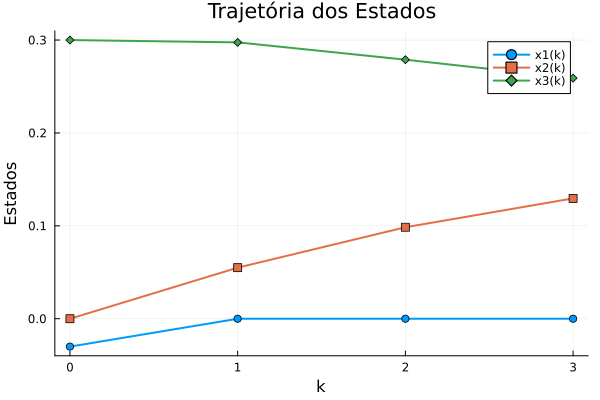

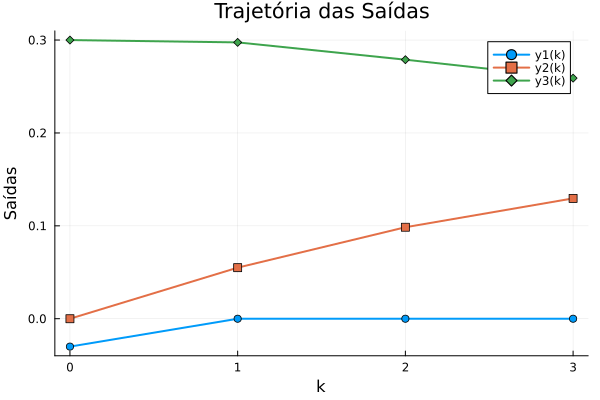

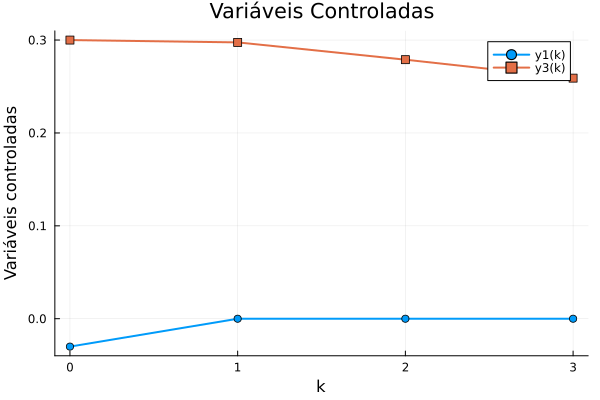

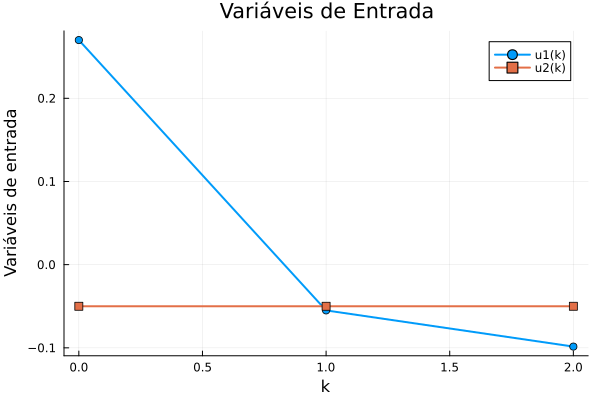

In [91]:
# =========================================================
# codificar e gerar alguns gráficos
# =========================================================
using Plots

# Resolver o modelo
optimize!(model)

println("Status = ", termination_status(model))
println("Valor da função objetivo = ", objective_value(model))

# Extrair resultados
x_opt = [value(x[i,k]) for i in 1:3, k in 0:N]
u_opt = [value(u[j,k]) for j in 1:2, k in 0:N-1]
y_opt = [value(y[i,k]) for i in 1:3, k in 0:N]

println("\nEstados ótimos:")
for k in 0:N
    println("x(:,", k, ") = ", x_opt[:,k+1])
end

println("\nEntradas ótimas:")
for k in 0:N-1
    println("u(:,", k, ") = ", u_opt[:,k+1])
end

println("\nSaídas:")
for k in 0:N
    println("y(:,", k, ") = ", y_opt[:,k+1])
end

# Gráfico dos estados
k_y = 0:N
p_states = plot(
    k_y, x_opt[1,:],
    marker = :circle,
    linewidth = 2,
    label = "x1(k)",
    xlabel = "k",
    ylabel = "Estados",
    title = "Trajetória dos Estados"
)
plot!(p_states, k_y, x_opt[2,:], marker = :square, linewidth = 2, label = "x2(k)")
plot!(p_states, k_y, x_opt[3,:], marker = :diamond, linewidth = 2, label = "x3(k)")
display(p_states)

# Gráfico das saídas
p_outputs = plot(
    k_y, y_opt[1,:],
    marker = :circle,
    linewidth = 2,
    label = "y1(k)",
    xlabel = "k",
    ylabel = "Saídas",
    title = "Trajetória das Saídas"
)
plot!(p_outputs, k_y, y_opt[2,:], marker = :square, linewidth = 2, label = "y2(k)")
plot!(p_outputs, k_y, y_opt[3,:], marker = :diamond, linewidth = 2, label = "y3(k)")
display(p_outputs)

# =========================================================
# plotar variáveis controladas e variáveis de entrada
# =========================================================

k_y = 0:N
k_u = 0:N-1

# Variáveis controladas: y1 e y3
p1 = plot(
    k_y, y_opt[1,:],
    marker = :circle,
    linewidth = 2,
    label = "y1(k)",
    xlabel = "k",
    ylabel = "Variáveis controladas",
    title = "Variáveis Controladas"
)
plot!(p1, k_y, y_opt[3,:], marker = :square, linewidth = 2, label = "y3(k)")
display(p1)

# Variáveis de entrada: u1 e u2
p2 = plot(
    k_u, u_opt[1,:],
    marker = :circle,
    linewidth = 2,
    label = "u1(k)",
    xlabel = "k",
    ylabel = "Variáveis de entrada",
    title = "Variáveis de Entrada"
)
plot!(p2, k_u, u_opt[2,:], marker = :square, linewidth = 2, label = "u2(k)")
display(p2)